In [ ]:
# ===============================================
# IMPORT LIBRARIES
# ===============================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Seleksi Fitur & Target

In [20]:
df = sns.load_dataset("titanic")
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


In [22]:
print(df.isna().sum)

<bound method DataFrame.sum of      survived  pclass    sex    age  sibsp  parch   fare  embarked
0       False   False  False  False  False  False  False     False
1       False   False  False  False  False  False  False     False
2       False   False  False  False  False  False  False     False
3       False   False  False  False  False  False  False     False
4       False   False  False  False  False  False  False     False
..        ...     ...    ...    ...    ...    ...    ...       ...
886     False   False  False  False  False  False  False     False
887     False   False  False  False  False  False  False     False
888     False   False  False   True  False  False  False     False
889     False   False  False  False  False  False  False     False
890     False   False  False  False  False  False  False     False

[891 rows x 8 columns]>


In [23]:
num_cols = ['age','sibsp','parch','fare']
cat_cols = ['pclass','sex','embarked']
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessing = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])
X = df[num_cols + cat_cols]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")



Training set size: (712, 7)
Test set size: (179, 7)


### SOAL 1: DecisionTreeClassifier Model

In [24]:
model_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
# Train the model
print("\n" + "="*50)
print("SOAL 1: Training DecisionTreeClassifier")
print("="*50)
model_pipeline.fit(X_train, y_train)
# Initial evaluation
y_pred = model_pipeline.predict(X_test)
train_score = model_pipeline.score(X_train, y_train)
test_score = model_pipeline.score(X_test, y_test)

print(f"\nInitial Model Performance:")
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


SOAL 1: Training DecisionTreeClassifier

Initial Model Performance:
Training Accuracy: 0.9789
Test Accuracy: 0.7933

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       105
           1       0.73      0.78      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179


Confusion Matrix:
[[84 21]
 [16 58]]


### SOAL 2: Hyperparameter Tuning & Best Model

In [26]:
print("\n" + "="*60)
print("SOAL 2: HYPERPARAMETER TUNING")
print("="*60)

# Define hyperparameter grid
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 'log2', None]
}

print("\nHyperparameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Perform GridSearchCV
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Performing Grid Search (this may take a few minutes)...\n")
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_

print(f"\n✓ Grid Search completed!")
print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param.replace('classifier__', '')}: {value}")



SOAL 2: HYPERPARAMETER TUNING

Hyperparameter Grid:
  classifier__max_depth: [3, 5, 7, 10, None]
  classifier__min_samples_split: [2, 5, 10, 20]
  classifier__min_samples_leaf: [1, 2, 4, 8]
  classifier__criterion: ['gini', 'entropy']
  classifier__max_features: ['sqrt', 'log2', None]

🔍 Performing Grid Search (this may take a few minutes)...

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

✓ Grid Search completed!

Best Hyperparameters:
  criterion: entropy
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 20


In [27]:

# ===============================================
# EVALUATE BEST MODEL
# ===============================================
print("\n" + "="*60)
print("BEST MODEL EVALUATION")
print("="*60)

y_pred_best = best_model.predict(X_test)
train_score_best = best_model.score(X_train, y_train)
test_score_best = best_model.score(X_test, y_test)

print(f"\nBest Model Performance:")
print(f"  Training Accuracy: {train_score_best:.4f}")
print(f"  Test Accuracy: {test_score_best:.4f}")
print(f"  Cross-validation Score: {grid_search.best_score_:.4f}")

print(f"\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

print(f"\nConfusion Matrix (Best Model):")
print(confusion_matrix(y_test, y_pred_best))




BEST MODEL EVALUATION

Best Model Performance:
  Training Accuracy: 0.8258
  Test Accuracy: 0.8045
  Cross-validation Score: 0.8273

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix (Best Model):
[[92 13]
 [22 52]]


In [28]:
# ===============================================
# MODEL COMPARISON
# ===============================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
improvement = test_score_best - test_score
improvement_pct = (improvement / test_score) * 100

print(f"\n{'Metric':<30} {'Initial':<15} {'Best':<15} {'Change':<15}")
print("-" * 75)
print(f"{'Test Accuracy':<30} {test_score:<15.4f} {test_score_best:<15.4f} {improvement:+.4f}")
print(f"{'Training Accuracy':<30} {train_score:<15.4f} {train_score_best:<15.4f} {train_score_best-train_score:+.4f}")
print(f"\n✓ Improvement: {improvement:.4f} ({improvement_pct:+.2f}%)")

# ===============================================
# FEATURE IMPORTANCE
# ===============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# Get the classifier from the pipeline
best_classifier = best_model.named_steps['classifier']

# Get feature names after preprocessing
feature_names = (num_cols + 
                list(best_model.named_steps['preprocessing']
                    .named_transformers_['cat']
                    .named_steps['onehot']
                    .get_feature_names_out(cat_cols)))

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))




MODEL COMPARISON

Metric                         Initial         Best            Change         
---------------------------------------------------------------------------
Test Accuracy                  0.7933          0.8045          +0.0112
Training Accuracy              0.9789          0.8258          -0.1531

✓ Improvement: 0.0112 (+1.41%)

FEATURE IMPORTANCE

Top 10 Most Important Features:
   feature  importance
sex_female    0.556768
  pclass_2    0.129413
  pclass_1    0.107914
      fare    0.100547
       age    0.063197
     sibsp    0.033928
     parch    0.005880
embarked_Q    0.002355
  pclass_3    0.000000
  sex_male    0.000000



VISUALISASI POHON KEPUTUSAN

✓ Pohon keputusan telah disimpan sebagai 'decision_tree_visualization.png'


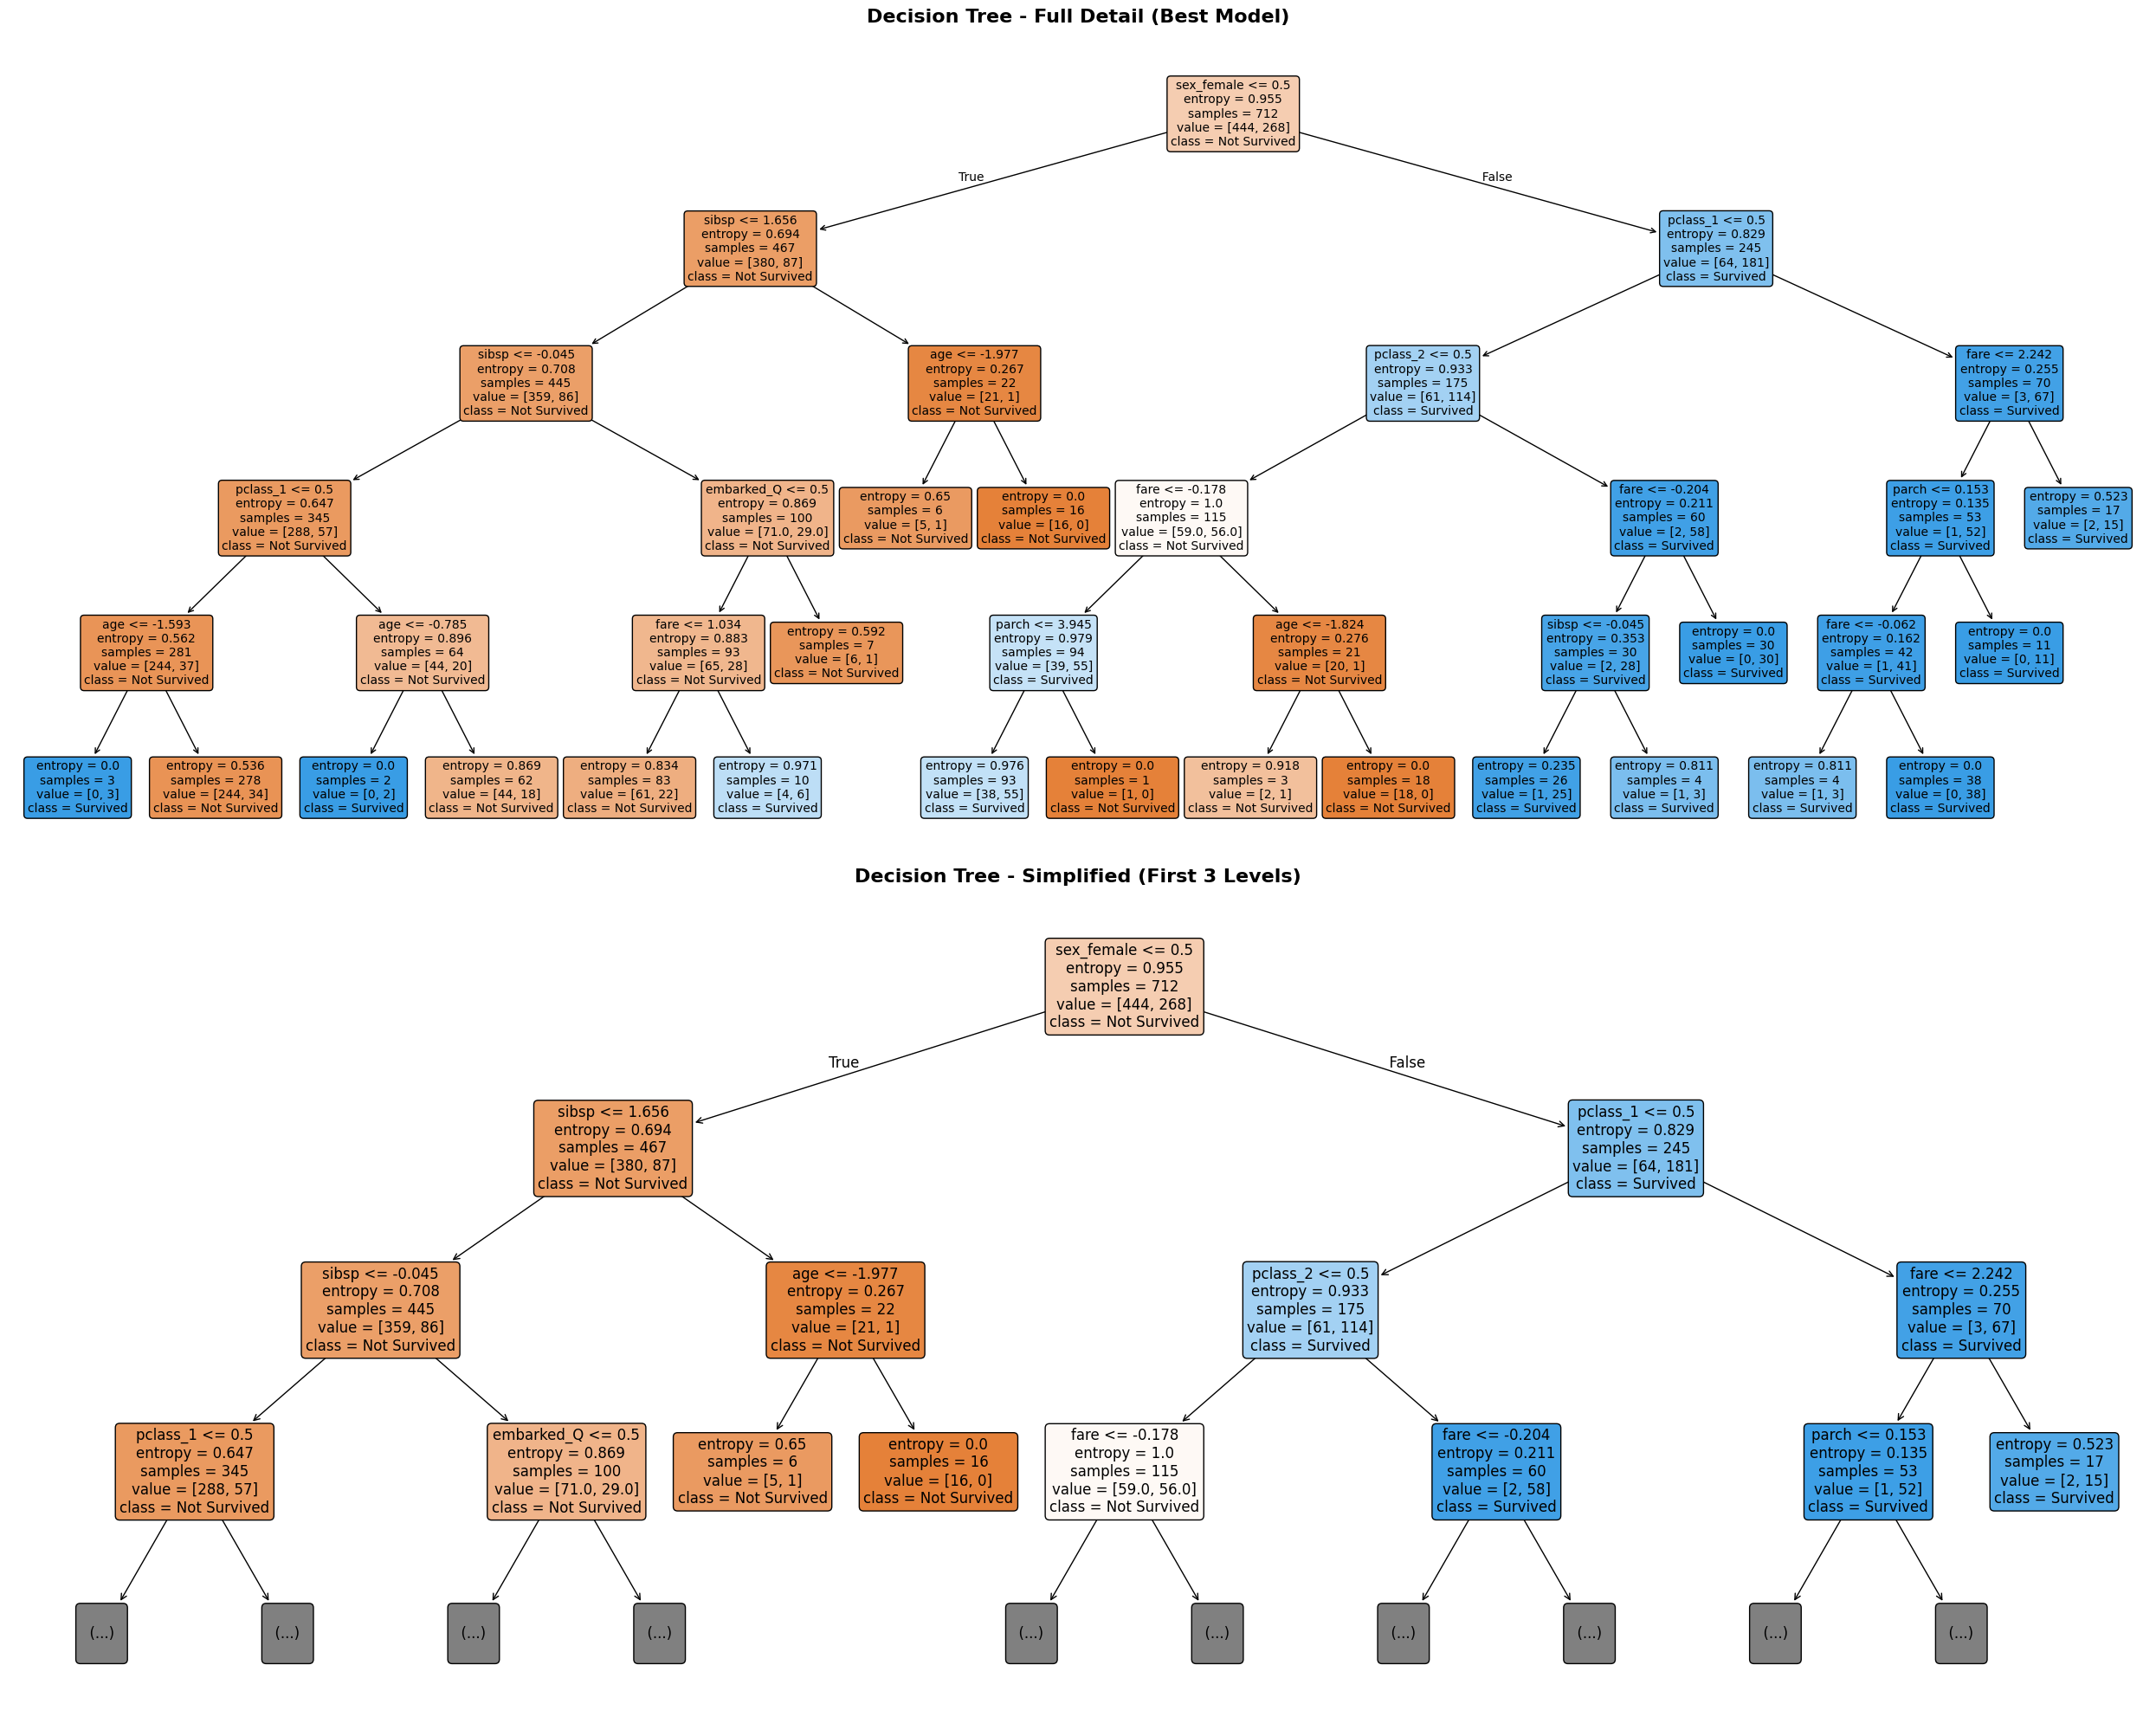


Statistik Pohon Keputusan:
  - Jumlah nodes: 39
  - Jumlah leaves: 20
  - Kedalaman maksimum: 5
  - Jumlah fitur yang digunakan: 12

✓ SELESAI!


In [29]:
# ===============================================
# VISUALISASI POHON KEPUTUSAN
# ===============================================
print("\n" + "="*60)
print("VISUALISASI POHON KEPUTUSAN")
print("="*60)

# Visualisasi pohon dari best model
fig, axes = plt.subplots(2, 1, figsize=(25, 20))

# Plot 1: Pohon lengkap (detail)
plot_tree(best_classifier, 
          feature_names=feature_names,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=axes[0])
axes[0].set_title('Decision Tree - Full Detail (Best Model)', 
                  fontsize=16, fontweight='bold', pad=20)

# Plot 2: Pohon dengan kedalaman terbatas (lebih mudah dibaca)
plot_tree(best_classifier, 
          feature_names=feature_names,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=3,  # Hanya tampilkan 3 level pertama
          ax=axes[1])
axes[1].set_title('Decision Tree - Simplified (First 3 Levels)', 
                  fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ Pohon keputusan telah disimpan sebagai 'decision_tree_visualization.png'")
plt.show()

# Statistik pohon
print(f"\nStatistik Pohon Keputusan:")
print(f"  - Jumlah nodes: {best_classifier.tree_.node_count}")
print(f"  - Jumlah leaves: {best_classifier.tree_.n_leaves}")
print(f"  - Kedalaman maksimum: {best_classifier.tree_.max_depth}")
print(f"  - Jumlah fitur yang digunakan: {len(feature_names)}")

print("\n" + "="*60)
print("✓ SELESAI!")
print("="*60)